# SCENARIO 1 – Multinomial Naive Bayes

In [2]:
import pandas as pd
import numpy as np
import re, string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Name: Mohamed Aashik S \nRoll No: 24BAD072\n")


Name: Mohamed Aashik S 
Roll No: 24BAD072



In [3]:
df = pd.read_csv('C:\\Users\\Mohamed Aashik\\OneDrive - Kumaraguru College of Technology\\Assignment\\ML\\ML Repo\\EX 4-Probabilistic Classification using Naive\\Dataset\\spam.csv', encoding='latin-1')
df = df[['v1','v2']]
df.columns = ['label','message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    text = re.sub(r'\d+', '', text)
    return text

df['clean_msg'] = df['message'].apply(clean_text)

In [5]:
cv = CountVectorizer()
X = cv.fit_transform(df['clean_msg'])

le = LabelEncoder()
y = le.fit_transform(df['label'])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [7]:
model = MultinomialNB(alpha=1.0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9704035874439462
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       965
           1       0.88      0.91      0.89       150

    accuracy                           0.97      1115
   macro avg       0.93      0.94      0.94      1115
weighted avg       0.97      0.97      0.97      1115



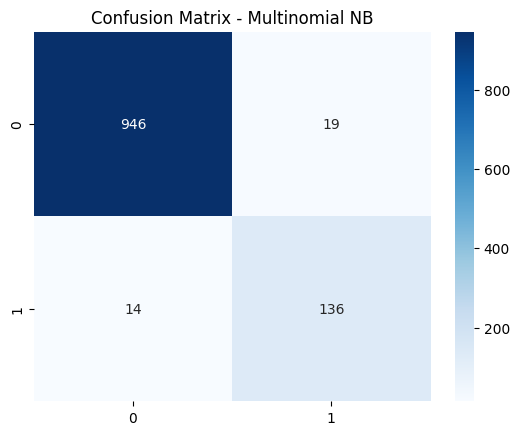

In [8]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Multinomial NB')
plt.show()

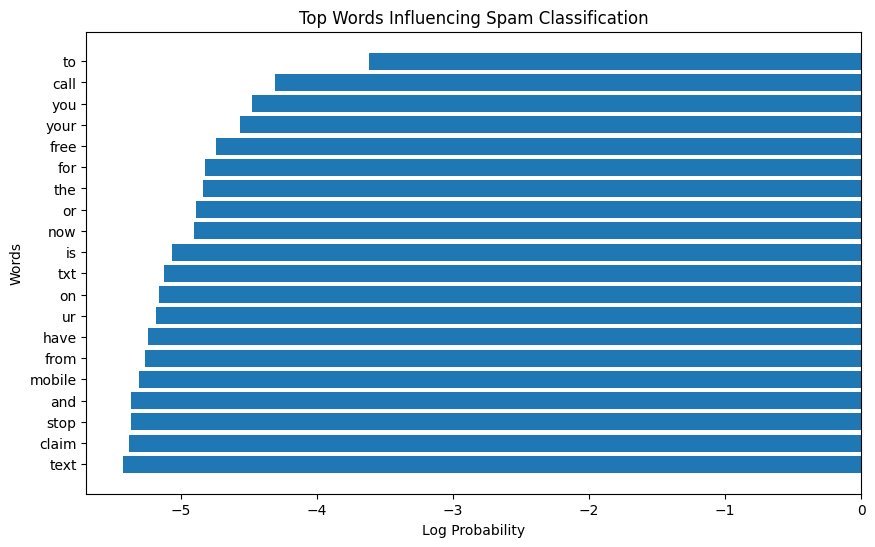

In [ ]:
feature_names = cv.get_feature_names_out()
spam_probs = model.feature_log_prob_[1]
top_indices = np.argsort(spam_probs)[-20:]
top_words = feature_names[top_indices]
top_values = spam_probs[top_indices]

plt.figure(figsize=(10,6))
plt.barh(top_words, top_values)
plt.title("Top Words Influencing Spam Classification")
plt.xlabel("Log Probability")
plt.ylabel("Words")
plt.show()

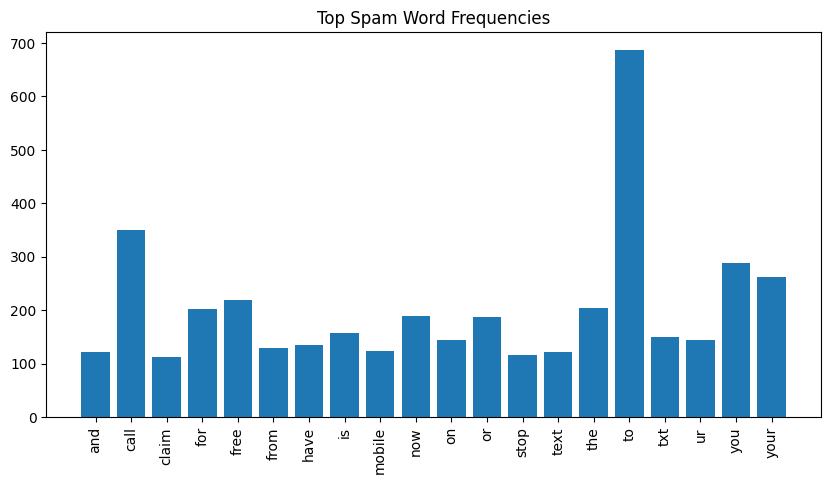

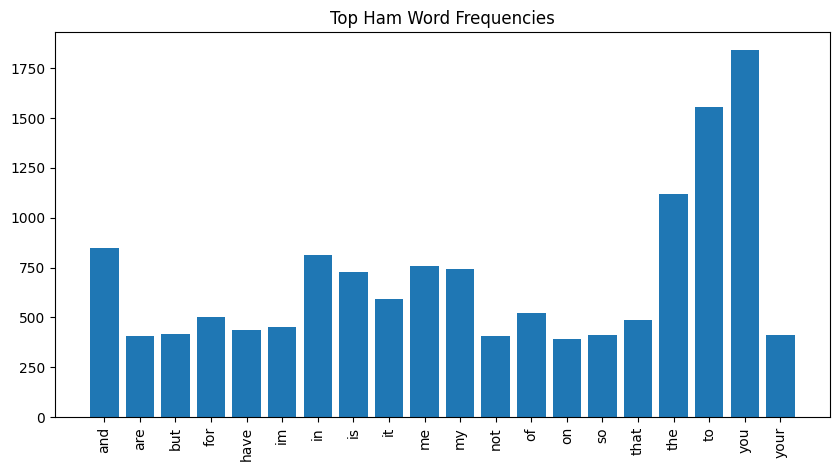

In [ ]:
spam_msgs = df[df['label']=='spam']['clean_msg']
ham_msgs  = df[df['label']=='ham']['clean_msg']

cv_spam = CountVectorizer(max_features=20)
cv_ham  = CountVectorizer(max_features=20)

spam_vec = cv_spam.fit_transform(spam_msgs)
ham_vec  = cv_ham.fit_transform(ham_msgs)

spam_sum = np.array(spam_vec.sum(axis=0)).flatten()
ham_sum  = np.array(ham_vec.sum(axis=0)).flatten()

spam_words = cv_spam.get_feature_names_out()
ham_words  = cv_ham.get_feature_names_out()

plt.figure(figsize=(10,5))
plt.bar(spam_words, spam_sum)
plt.xticks(rotation=90)
plt.title("Top Spam Word Frequencies")
plt.show()

plt.figure(figsize=(10,5))
plt.bar(ham_words, ham_sum)
plt.xticks(rotation=90)
plt.title("Top Ham Word Frequencies")
plt.show()


# SCENARIO 2 – Gaussian Naive Bayes

In [11]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

In [12]:
iris = load_iris()
X = iris.data
y = iris.target

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [14]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



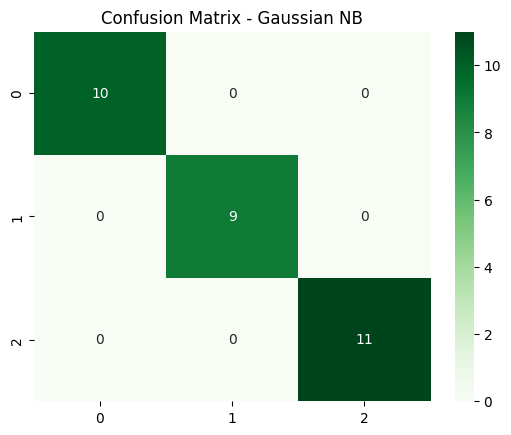

In [15]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Gaussian NB')
plt.show()

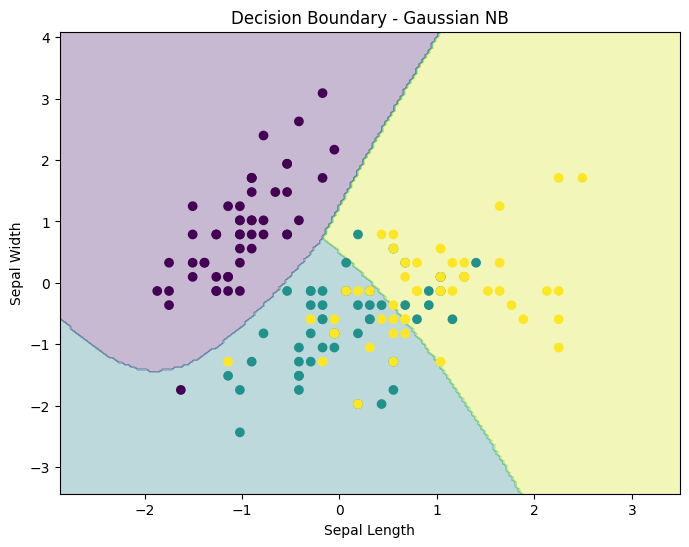

In [ ]:
X2 = X_scaled[:, :2]

X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42)

gnb.fit(X_train, y_train)

x_min, x_max = X2[:,0].min()-1, X2[:,0].max()+1
y_min, y_max = X2[:,1].min()-1, X2[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = gnb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2[:,0], X2[:,1], c=y)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Decision Boundary - Gaussian NB")
plt.show()

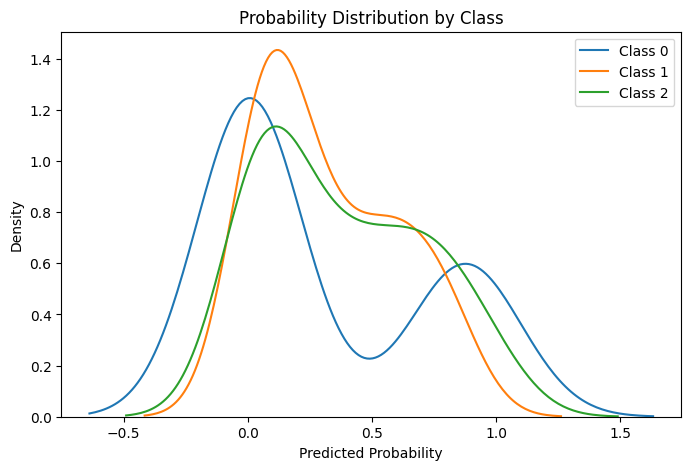

In [ ]:
probs = gnb.predict_proba(X_test)

plt.figure(figsize=(8,5))

for i in range(3):
    sns.kdeplot(probs[:, i], label=f"Class {i}")

plt.title("Probability Distribution by Class")
plt.xlabel("Predicted Probability")
plt.legend()
plt.show()